# 03. Preprocessing and Modeling

This notebook defines model-specific preprocessing, develops and tunes the required classifiers using the training set, compares their cross-validated development performance, and then evaluates the finalized models on the held-out test set.

The workflow is deliberately separated into two stages:

1. **Model development:** preprocessing, cross-validation, and hyperparameter selection use training data only.
2. **Final evaluation:** the untouched test set is used after model development to compare final predictive performance.

## 1. Setup

All imports are kept in one place to avoid repeating them throughout the notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    cross_val_predict,
    GridSearchCV
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis,
    QuadraticDiscriminantAnalysis
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    GradientBoostingClassifier
)
from sklearn.svm import SVC

## 2. Load Engineered Train and Test Sets

The engineered train and test sets were created in Notebook 02. The split is therefore preserved exactly as used during EDA and feature engineering.

In [2]:
train_df = pd.read_csv("forest_fires_train_engineered.csv")
test_df = pd.read_csv("forest_fires_test_engineered.csv")

print("Training shape:", train_df.shape)
print("Test shape:", test_df.shape)

Training shape: (195, 13)
Test shape: (49, 13)


## 3. Define Predictors and Target

`fire` is encoded as the positive class (`1`) and `not fire` as the negative class (`0`). This makes the interpretation of precision, recall, specificity, F1, and ROC-AUC explicit.

In [3]:
X_train = train_df.drop(columns="Classes")
y_train = train_df["Classes"]

X_test = test_df.drop(columns="Classes")
y_test = test_df["Classes"]

target_mapping = {
    "not fire": 0,
    "fire": 1
}

y_train = y_train.map(target_mapping)
y_test = y_test.map(target_mapping)

print(y_train.value_counts().sort_index())

Classes
0     85
1    110
Name: count, dtype: int64


## 4. Preprocessing and Evaluation Setup

Preprocessing is attached directly to model pipelines. This ensures that transformations are fitted only on the training portion of each cross-validation fold and prevents data leakage.

### 4.1 Feature Groups

In [4]:
numeric_features = [
    "Temperature",
    "RH",
    "Ws",
    "Rain",
    "FFMC",
    "DMC",
    "DC",
    "ISI",
    "BUI",
    "FWI",
    "DayOfYear"
]

categorical_features = ["Region"]

### 4.2 Preprocessor for Scale-Sensitive Models

Logistic Regression, LDA, QDA, KNN, and SVM use the scaled preprocessor. Numerical variables are standardized and `Region` is one-hot encoded.

Scaling is especially important for distance-based KNN and margin-based SVM. For Logistic Regression it also improves numerical conditioning and makes standardized coefficients easier to compare. LDA and QDA do not strictly require scaling, but using the same representation keeps their comparison consistent.

In [5]:
scaled_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                drop="if_binary",
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

### 4.3 Preprocessor for Tree-Based Models

Tree models do not require numerical scaling because splits depend on ordering and threshold comparisons rather than distances. Numerical variables are therefore passed through unchanged, while `Region` is still one-hot encoded.

In [6]:
tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            "passthrough",
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                drop="if_binary",
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

### 4.4 Cross-Validation Strategy

Five-fold stratified cross-validation is used throughout model development. Stratification preserves approximately the same class proportions in each fold, which is appropriate for this binary classification problem.

The same folds are used across models so that comparisons are made under consistent conditions. Accuracy is used as the primary tuning criterion, while precision, recall, specificity, F1, and ROC-AUC are also reported for interpretation.

In [7]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

### 4.5 Reusable Evaluation Helpers

The following helper functions only standardize repeated evaluation and plotting code. They do not change how any model is trained.

Cross-validated results use out-of-fold predictions: every observation is predicted by a model that did not train on that observation.

In [8]:
def classification_summary(y_true, y_pred, y_score):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    return {
        "y_pred": y_pred,
        "y_score": y_score,
        "confusion_matrix": cm,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "specificity": tn / (tn + fp),
        "f1": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_score)
    }


def score_method_for_model(model):
    """Choose a continuous score for ROC/AUC without requiring probability calibration."""
    estimator = model.named_steps.get("model", model) if isinstance(model, Pipeline) else model

    if hasattr(estimator, "predict_proba"):
        return "predict_proba"
    if hasattr(estimator, "decision_function"):
        return "decision_function"

    raise AttributeError("Model must provide predict_proba or decision_function.")


def evaluate_cv_model(model, X, y, cv):
    y_pred = cross_val_predict(
        model,
        X,
        y,
        cv=cv,
        method="predict"
    )

    score_method = score_method_for_model(model)
    y_score = cross_val_predict(
        model,
        X,
        y,
        cv=cv,
        method=score_method
    )

    if score_method == "predict_proba":
        y_score = y_score[:, 1]

    return classification_summary(y, y_pred, y_score)


def continuous_score(fitted_model, X):
    if hasattr(fitted_model, "predict_proba"):
        return fitted_model.predict_proba(X)[:, 1]
    if hasattr(fitted_model, "decision_function"):
        return fitted_model.decision_function(X)
    raise AttributeError("Model must provide predict_proba or decision_function.")


def results_table(results, include_auc=True):
    rows = []

    for model_name, result in results.items():
        row = {
            "Model": model_name,
            "Accuracy": result["accuracy"],
            "Precision": result["precision"],
            "Recall": result["recall"],
            "Specificity": result["specificity"],
            "F1 Score": result["f1"]
        }

        if include_auc:
            row["ROC-AUC"] = result["roc_auc"]

        rows.append(row)

    return pd.DataFrame(rows)


def plot_confusion_matrices(results):
    for model_name, result in results.items():
        fig, ax = plt.subplots(figsize=(7, 6))

        sns.heatmap(
            result["confusion_matrix"],
            annot=True,
            fmt="d",
            cmap="viridis",
            cbar=True,
            square=True,
            annot_kws={"size": 16},
            ax=ax
        )

        ax.set_title(f"Confusion Matrix - {model_name}", fontsize=16)
        ax.set_xlabel("Predicted Class")
        ax.set_ylabel("Actual Class")
        ax.set_xticklabels(["Not Fire", "Fire"])
        ax.set_yticklabels(["Not Fire", "Fire"], rotation=0)

        plt.tight_layout()
        plt.show()


def plot_metric_bars(results):
    metric_labels = [
        "Accuracy", "Precision", "Recall", "Specificity", "F1 Score"
    ]
    result_keys = [
        "accuracy", "precision", "recall", "specificity", "f1"
    ]

    for model_name, result in results.items():
        values = [result[key] for key in result_keys]

        plt.figure(figsize=(8, 5))
        bars = plt.bar(metric_labels, values, width=0.5)

        plt.title(f"Classification Metrics - {model_name}")
        plt.xlabel("Metric")
        plt.ylabel("Metric Value")
        plt.ylim(0, 1.05)

        for bar, value in zip(bars, values):
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                value + 0.02,
                f"{value * 100:.1f}%",
                ha="center",
                va="bottom"
            )

        plt.tight_layout()
        plt.show()


def plot_roc_curves(results, y_true, title):
    plt.figure(figsize=(9, 7))

    for model_name, result in results.items():
        fpr, tpr, _ = roc_curve(y_true, result["y_score"])

        plt.plot(
            fpr,
            tpr,
            label=f'{model_name} (AUC = {result["roc_auc"]:.3f})'
        )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Random Classifier"
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.tight_layout()
    plt.show()


def clean_feature_names(feature_names):
    cleaned = []

    for name in feature_names:
        name = name.replace("num__", "")
        name = name.replace("cat__Region_", "Region: ")
        cleaned.append(name)

    return cleaned

## 5. Modeling

All tuning and model development in Sections 5.1-5.4 use only the training set. The held-out test set is evaluated once, after all model choices have been finalized.

### 5.1 Logistic Regression, LDA and QDA

These three classical classifiers are first compared under the same preprocessing and cross-validation setup.

#### 5.1.1 Logistic Regression

Logistic Regression directly models the probability of the positive class. The scaled preprocessor is included inside the pipeline so that scaling is learned separately within each cross-validation training fold.

In [9]:
logistic_pipeline = Pipeline([
    ("preprocessing", scaled_preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

#### 5.1.2 Linear Discriminant Analysis (LDA)

LDA models the predictor distribution within each class and assumes that the classes share a common covariance structure. This produces a linear decision boundary.

In [10]:
lda_pipeline = Pipeline([
    ("preprocessing", scaled_preprocessor),
    ("model", LinearDiscriminantAnalysis())
])

#### 5.1.3 Quadratic Discriminant Analysis (QDA)

QDA allows each class to have its own covariance matrix, producing a quadratic decision boundary. This added flexibility can be useful, but QDA may be sensitive to small samples and strongly correlated predictors.

In [11]:
qda_pipeline = Pipeline([
    ("preprocessing", scaled_preprocessor),
    ("model", QuadraticDiscriminantAnalysis())
])

#### 5.1.4 Cross-Validated Comparison

The three models are evaluated using out-of-fold predictions from the same five stratified folds. The confusion matrices, classification metrics, and ROC curves describe performance on the training set without using the held-out test set.

In [12]:
models_5_1 = {
    "Logistic Regression": logistic_pipeline,
    "LDA": lda_pipeline,
    "QDA": qda_pipeline
}

results_5_1 = {
    model_name: evaluate_cv_model(model, X_train, y_train, cv)
    for model_name, model in models_5_1.items()
}

results_table(results_5_1).round(3)

,Model,Accuracy,Precision,Recall,Specificity,F1 Score,ROC-AUC
0,Logistic Regression,0.964,0.964,0.973,0.953,0.968,0.995
1,LDA,0.928,0.944,0.927,0.929,0.936,0.980
2,QDA,0.964,0.956,0.982,0.941,0.969,0.984


**Development result.** Logistic Regression and QDA both achieve 0.964 cross-validated accuracy, while LDA is lower at 0.928. Logistic Regression has the highest AUC of the three (0.995), whereas QDA has the highest recall (0.982). These results suggest strong class separation, but the coefficient interpretation below should remain cautious because several FWI predictors are highly correlated.

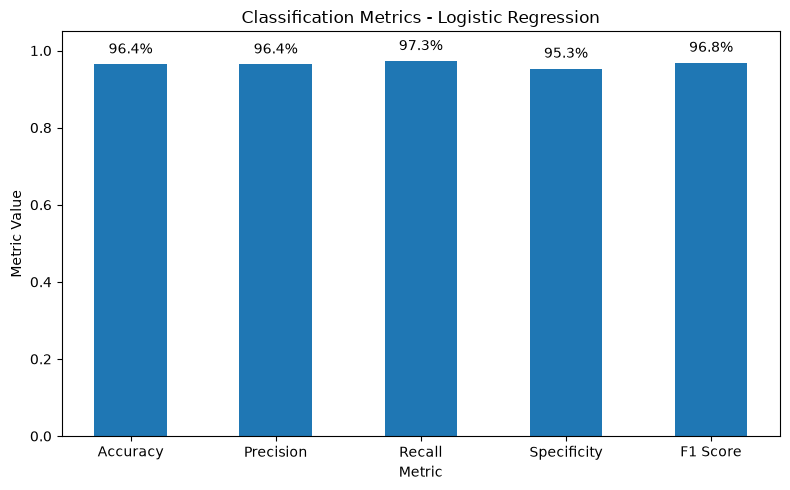

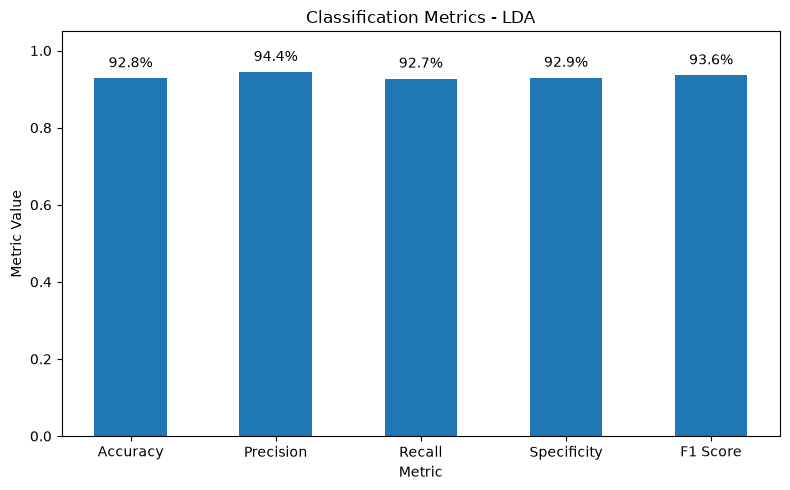

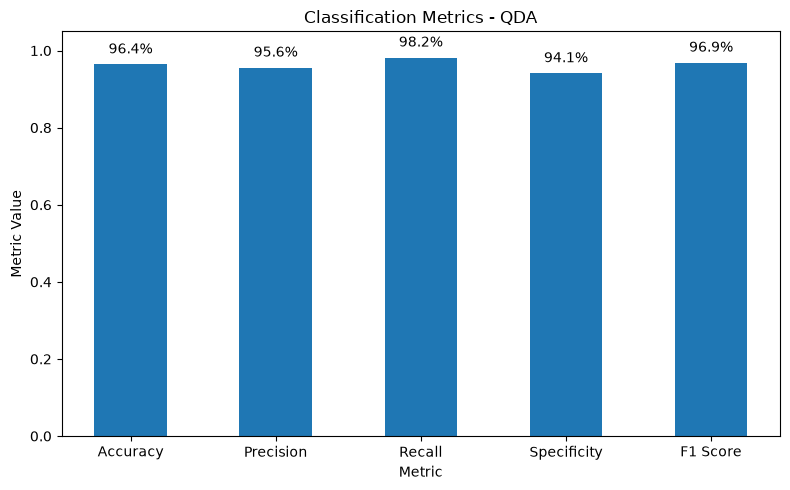

In [13]:
plot_metric_bars(results_5_1)

#### 5.1.5 Logistic Regression Coefficient Interpretation

Because the numerical predictors are standardized, the fitted Logistic Regression coefficients can be compared on a common scale. Positive coefficients push the model toward `fire`, while negative coefficients push it toward `not fire`.

Coefficient magnitude is not a universal feature-importance measure, and it should be interpreted cautiously because several Fire Weather Index variables are strongly correlated.

In [14]:
logistic_pipeline.fit(X_train, y_train)

logistic_feature_names = clean_feature_names(
    logistic_pipeline["preprocessing"].get_feature_names_out()
)

logistic_coefficients = logistic_pipeline["model"].coef_[0]

logistic_coef_df = pd.DataFrame({
    "Feature": logistic_feature_names,
    "Coefficient": logistic_coefficients
})

logistic_coef_df["Absolute Coefficient"] = (
    logistic_coef_df["Coefficient"].abs()
)

logistic_coef_df = logistic_coef_df.sort_values(
    "Absolute Coefficient",
    ascending=False
)

logistic_coef_df.round(3)

,Feature,Coefficient,Absolute Coefficient
4,FFMC,2.600,2.600
7,ISI,2.434,2.434
9,FWI,1.876,1.876
5,DMC,-0.367,0.367
8,BUI,0.352,0.352
1,RH,0.342,0.342
11,Region: Hudson Bay,0.301,0.301
3,Rain,0.217,0.217
6,DC,0.150,0.150
2,Ws,-0.138,0.138


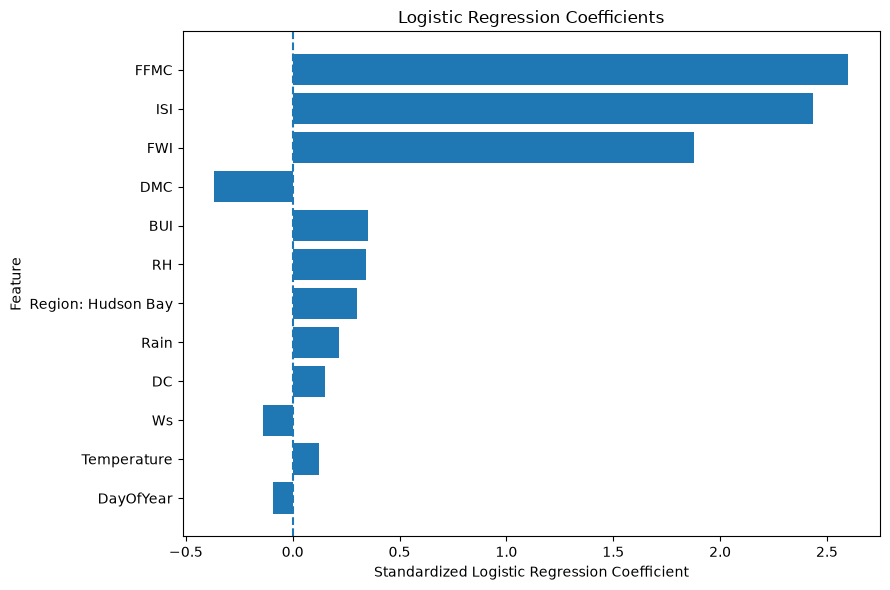

In [15]:
plt.figure(figsize=(9, 6))

plt.barh(
    logistic_coef_df["Feature"],
    logistic_coef_df["Coefficient"]
)

plt.axvline(0, linestyle="--")
plt.xlabel("Standardized Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Logistic Regression Coefficients")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### 5.2 K-Nearest Neighbors (KNN)

KNN predicts a class from the labels of nearby observations. Because the method relies directly on distances, the scaled preprocessor is required.

The main hyperparameter is the number of neighbors, `K`. Several odd values are compared using five-fold stratified cross-validation.

#### 5.2.1 Selection of K

Small values of `K` can be sensitive to noise, while very large values can oversmooth the decision boundary. Odd values from 1 to 25 are examined to reduce the possibility of tied votes in this binary classification problem.

In [16]:
k_values = range(1, 26, 2)
knn_cv_accuracy = []

for k in k_values:
    knn_pipeline = Pipeline([
        ("preprocessing", scaled_preprocessor),
        ("model", KNeighborsClassifier(n_neighbors=k))
    ])

    scores = cross_val_score(
        knn_pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy"
    )

    knn_cv_accuracy.append(scores.mean())

knn_k_results = pd.DataFrame({
    "K": list(k_values),
    "CV Accuracy": knn_cv_accuracy
})

knn_k_results.round(3)

,K,CV Accuracy
0,1,0.882
1,3,0.897
2,5,0.882
3,7,0.903
4,9,0.897
5,11,0.892
6,13,0.897
7,15,0.908
8,17,0.908
9,19,0.913


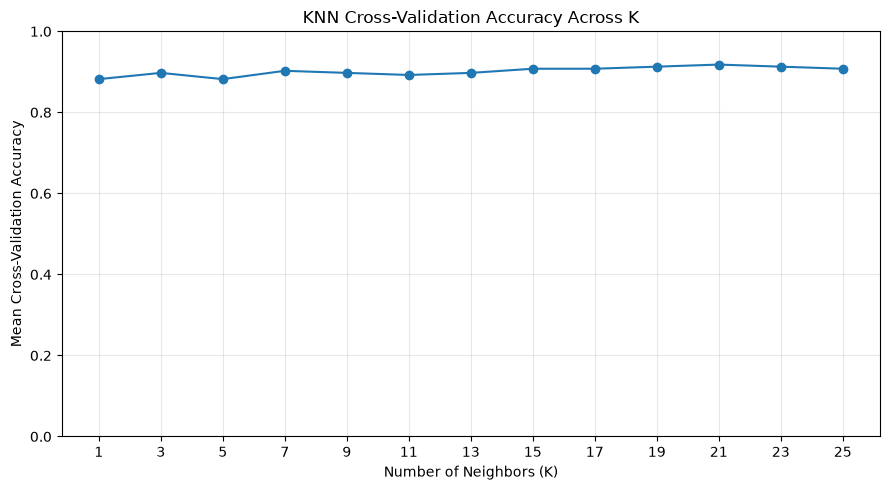

In [17]:
plt.figure(figsize=(9, 5))

plt.plot(
    knn_k_results["K"],
    knn_k_results["CV Accuracy"],
    marker="o"
)

plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Mean Cross-Validation Accuracy")
plt.title("KNN Cross-Validation Accuracy Across K")
plt.xticks(list(k_values))
plt.ylim(0, 1)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### 5.2.2 Selected KNN Model

The `K` value with the highest mean cross-validation accuracy is selected. This choice is made entirely from the training data.

In [18]:
best_k_index = knn_k_results["CV Accuracy"].idxmax()
best_k = int(knn_k_results.loc[best_k_index, "K"])
best_k_accuracy = knn_k_results.loc[best_k_index, "CV Accuracy"]

print("Best K:", best_k)
print("Mean CV Accuracy:", round(best_k_accuracy, 3))

best_knn_pipeline = Pipeline([
    ("preprocessing", scaled_preprocessor),
    ("model", KNeighborsClassifier(n_neighbors=best_k))
])

Best K: 21
Mean CV Accuracy: 0.918


#### 5.2.3 Cross-Validated Performance of the Selected KNN

The selected KNN model is evaluated using the same out-of-fold procedure and the same metrics used for the previous classifiers.

In [19]:
knn_results = {
    f"KNN (K = {best_k})": evaluate_cv_model(
        best_knn_pipeline,
        X_train,
        y_train,
        cv
    )
}

results_table(knn_results).round(3)

,Model,Accuracy,Precision,Recall,Specificity,F1 Score,ROC-AUC
0,KNN (K = 21),0.918,0.905,0.955,0.871,0.929,0.976


**Development result.** The best tested value is `K = 21`, with mean CV accuracy of 0.918. The selected KNN model has high recall (0.955) but lower specificity (0.871), indicating that it detects most fires while producing comparatively more false-positive fire predictions than the strongest competing models.

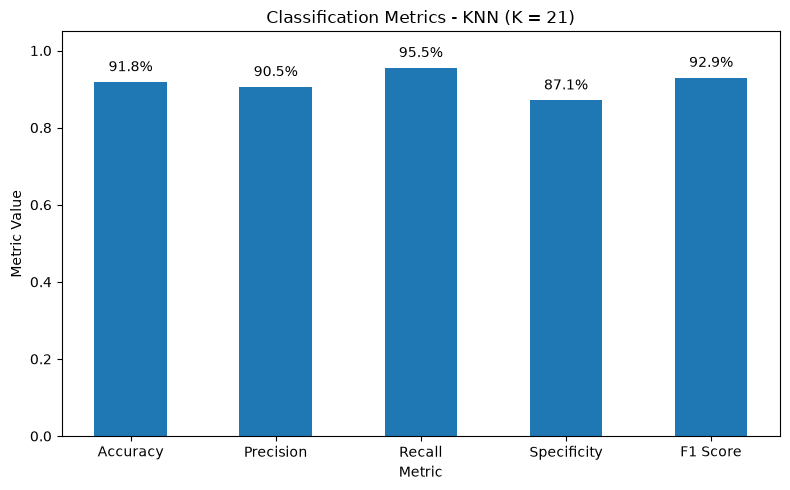

In [20]:
plot_metric_bars(knn_results)

### 5.3 Tree-Based Models

This section compares the required tree-based approaches:

1. Unpruned Decision Tree
2. Pruned Decision Tree
3. Bagging
4. Random Forest
5. Gradient Boosting

The tree preprocessor defined in Section 4.3 is reused here; it is not recreated.

#### 5.3.1 Unpruned Decision Tree

The unpruned tree is used as a baseline. It is allowed to grow without an explicit depth restriction, which makes it flexible but can also increase variance and overfitting.

In [21]:
unpruned_tree_pipeline = Pipeline([
    ("preprocessing", tree_preprocessor),
    (
        "model",
        DecisionTreeClassifier(random_state=42)
    )
])

#### 5.3.2 Cost-Complexity Pruning

Cost-complexity pruning controls tree size through `ccp_alpha`. Larger positive values penalize model complexity more strongly and remove more branches.

The unpruned tree already represents `ccp_alpha = 0`, so only **positive** candidate alpha values are considered for the pruned model. Candidate values are obtained from the pruning path of the training data and then evaluated using the same five-fold cross-validation procedure.

In [22]:
X_tree_for_path = tree_preprocessor.fit_transform(X_train)

pruning_path = DecisionTreeClassifier(
    random_state=42
).cost_complexity_pruning_path(
    X_tree_for_path,
    y_train
)

# ccp_alpha = 0 is the unpruned tree, and the largest alpha usually
# collapses the tree to a single root node. Both are excluded here.
alpha_values = np.unique(pruning_path.ccp_alphas[:-1])
alpha_values = alpha_values[alpha_values > 0]

pruning_cv_accuracy = []

for alpha in alpha_values:
    candidate_tree = Pipeline([
        ("preprocessing", tree_preprocessor),
        (
            "model",
            DecisionTreeClassifier(
                ccp_alpha=alpha,
                random_state=42
            )
        )
    ])

    scores = cross_val_score(
        candidate_tree,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy"
    )

    pruning_cv_accuracy.append(scores.mean())

pruning_results = pd.DataFrame({
    "ccp_alpha": alpha_values,
    "CV Accuracy": pruning_cv_accuracy
})

pruning_results.round(4)

,ccp_alpha,CV Accuracy
0,0.0077,0.9744
1,0.0223,0.9641


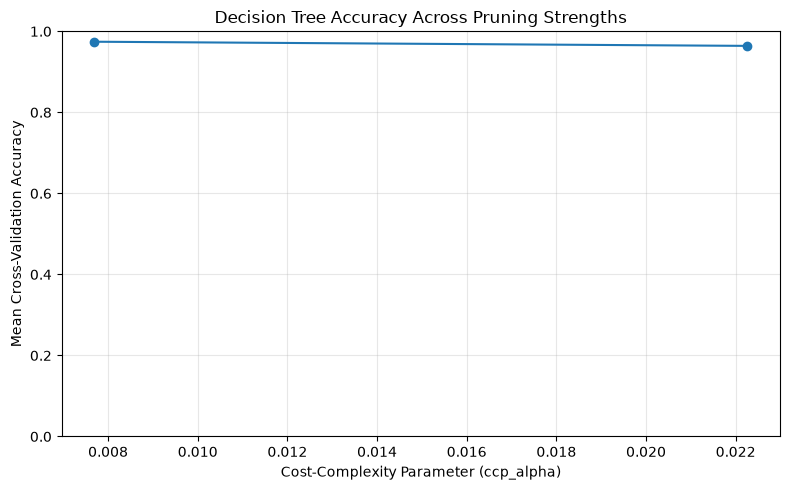

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(
    pruning_results["ccp_alpha"],
    pruning_results["CV Accuracy"],
    marker="o"
)

plt.xlabel("Cost-Complexity Parameter (ccp_alpha)")
plt.ylabel("Mean Cross-Validation Accuracy")
plt.title("Decision Tree Accuracy Across Pruning Strengths")
plt.ylim(0, 1)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### 5.3.3 Selected Pruned Tree and Complexity Comparison

Among the genuinely pruned candidates (`ccp_alpha > 0`), the value with the highest mean cross-validation accuracy is selected. This makes the comparison with the unpruned tree meaningful even if pruning does not improve accuracy.

The two trees are then fitted to the full training set only so that their depth and number of leaves can be compared.

In [24]:
best_alpha_index = pruning_results["CV Accuracy"].idxmax()
best_alpha = float(
    pruning_results.loc[best_alpha_index, "ccp_alpha"]
)
best_pruned_accuracy = pruning_results.loc[
    best_alpha_index,
    "CV Accuracy"
]

unpruned_cv_accuracy = cross_val_score(
    unpruned_tree_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring="accuracy"
).mean()

print("Unpruned mean CV accuracy:", round(unpruned_cv_accuracy, 3))
print("Best positive ccp_alpha:", best_alpha)
print("Pruned mean CV accuracy:", round(best_pruned_accuracy, 3))

pruned_tree_pipeline = Pipeline([
    ("preprocessing", tree_preprocessor),
    (
        "model",
        DecisionTreeClassifier(
            ccp_alpha=best_alpha,
            random_state=42
        )
    )
])

unpruned_tree_pipeline.fit(X_train, y_train)
pruned_tree_pipeline.fit(X_train, y_train)

unpruned_tree = unpruned_tree_pipeline["model"]
pruned_tree = pruned_tree_pipeline["model"]

tree_complexity = pd.DataFrame({
    "Model": ["Unpruned Tree", "Pruned Tree"],
    "Depth": [
        unpruned_tree.get_depth(),
        pruned_tree.get_depth()
    ],
    "Number of Leaves": [
        unpruned_tree.get_n_leaves(),
        pruned_tree.get_n_leaves()
    ]
})

tree_complexity

Unpruned mean CV accuracy: 0.974
Best positive ccp_alpha: 0.007692307692307693
Pruned mean CV accuracy: 0.974


,Model,Depth,Number of Leaves
0,Unpruned Tree,3,4
1,Pruned Tree,2,3


#### 5.3.4 Tree Visualization

The unpruned tree is displayed only to a limited depth so that the figure remains readable. This display limit does not change the fitted model. The pruned tree is shown separately to illustrate the effect of pruning.

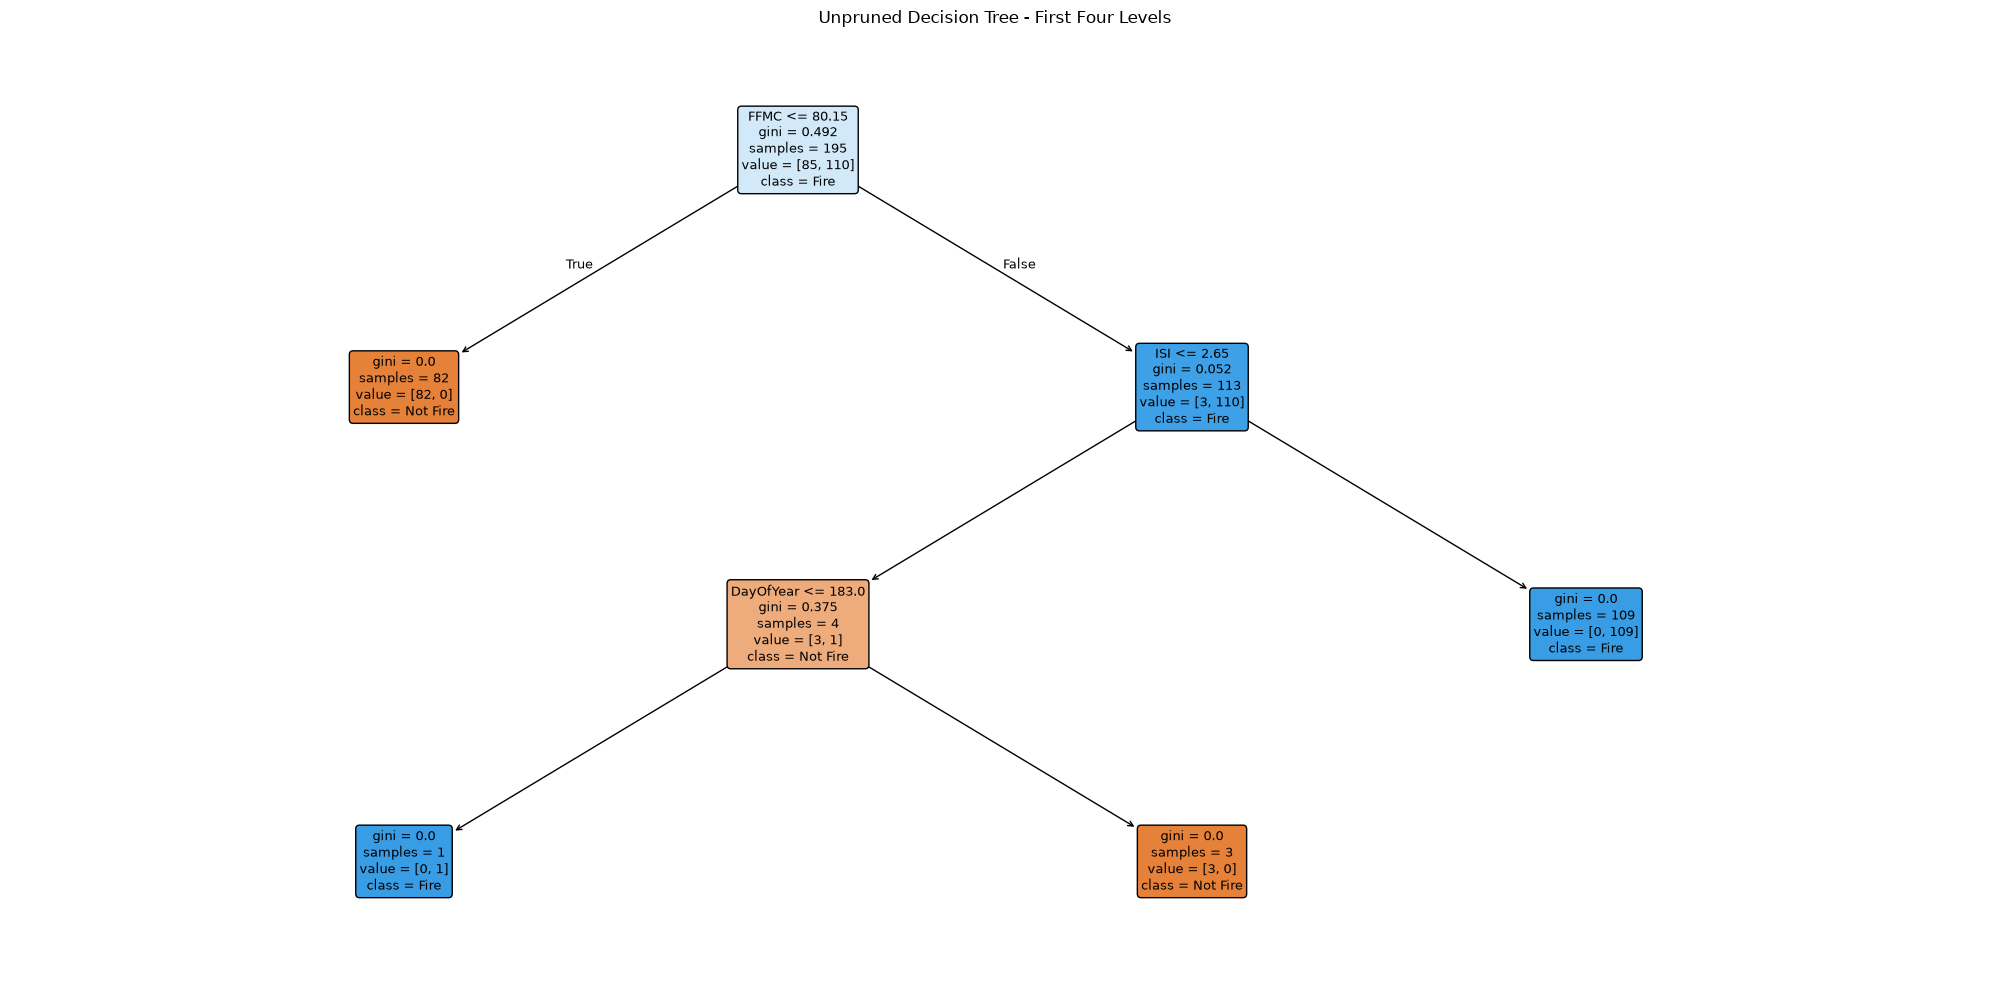

In [25]:
tree_feature_names = clean_feature_names(
    unpruned_tree_pipeline["preprocessing"].get_feature_names_out()
)

plt.figure(figsize=(20, 10))

plot_tree(
    unpruned_tree,
    feature_names=tree_feature_names,
    class_names=["Not Fire", "Fire"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9
)

plt.title("Unpruned Decision Tree - First Four Levels")
plt.tight_layout()
plt.show()

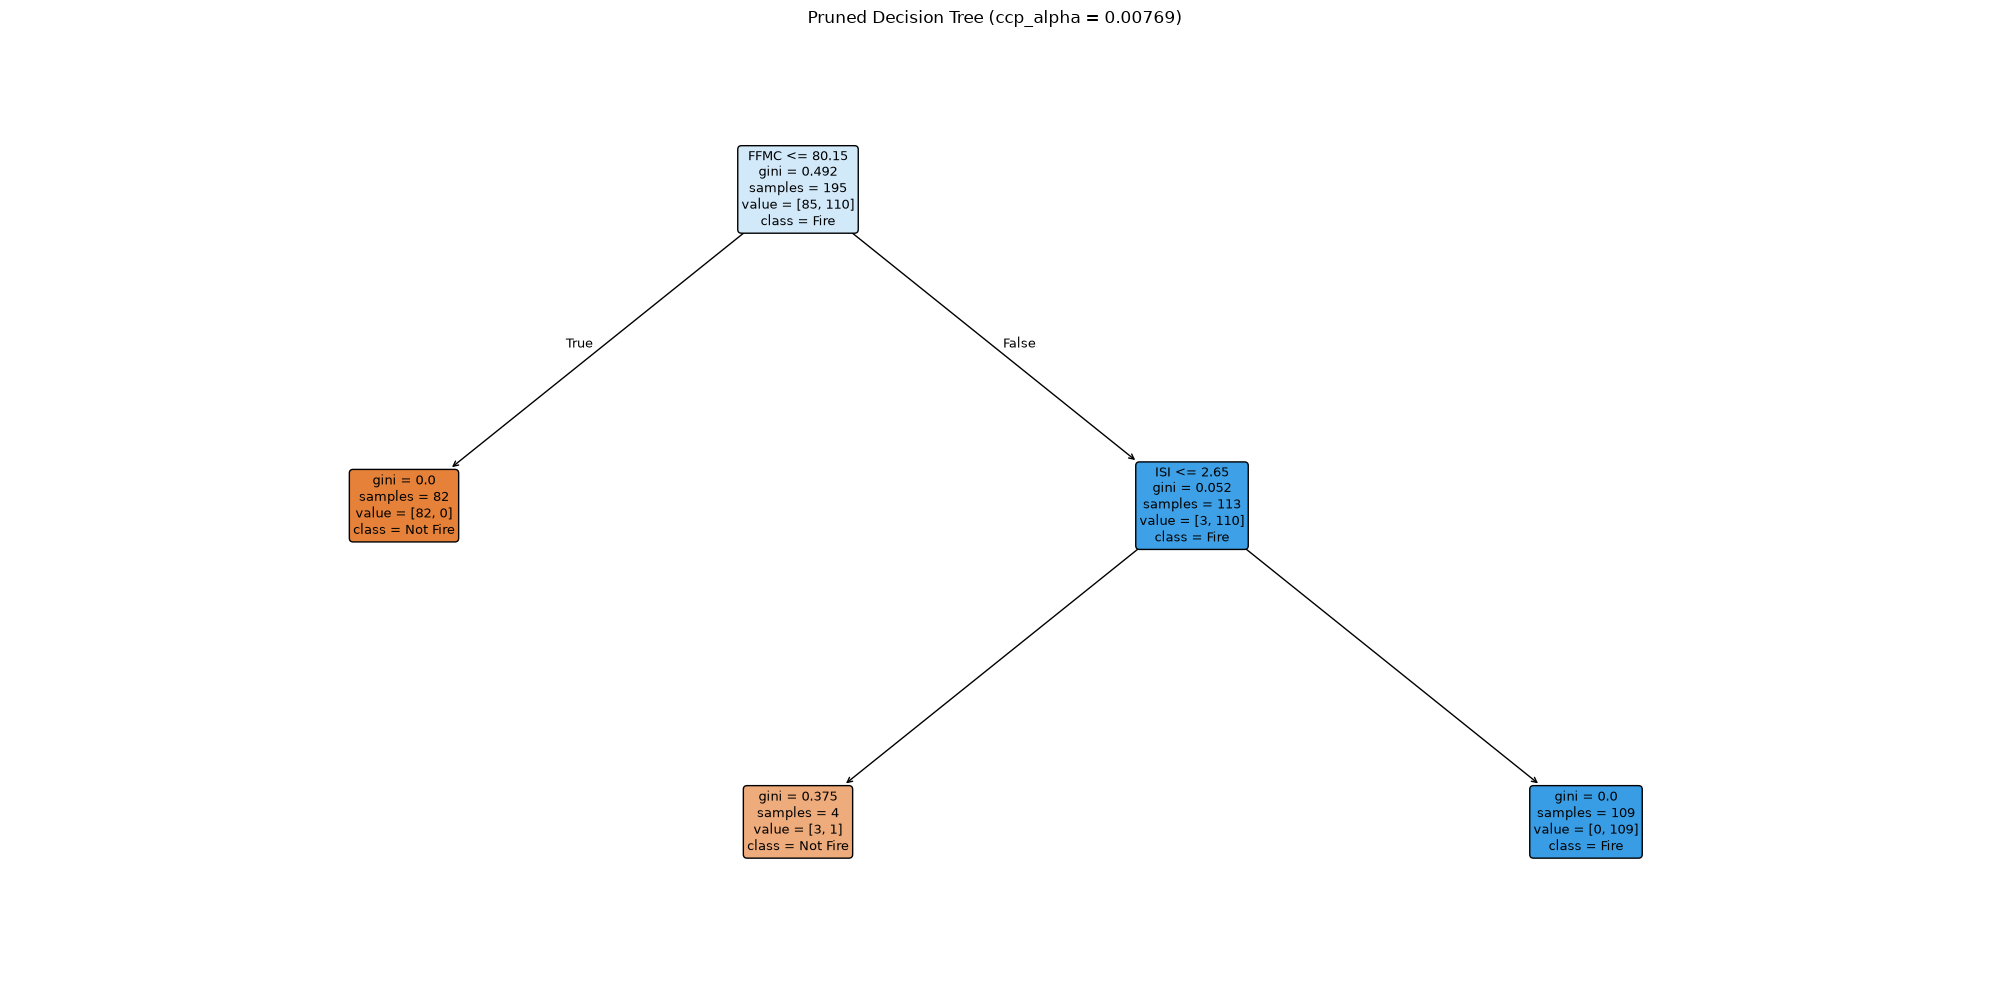

In [26]:
plt.figure(figsize=(20, 10))

plot_tree(
    pruned_tree,
    feature_names=tree_feature_names,
    class_names=["Not Fire", "Fire"],
    filled=True,
    rounded=True,
    max_depth=4,
    fontsize=9
)

plt.title(f"Pruned Decision Tree (ccp_alpha = {best_alpha:.5f})")
plt.tight_layout()
plt.show()

#### 5.3.5 Bagging

Bagging reduces the variance of a single decision tree by fitting many trees to bootstrap samples of the training data and combining their predictions.

In [27]:
bagging_pipeline = Pipeline([
    ("preprocessing", tree_preprocessor),
    (
        "model",
        BaggingClassifier(
            estimator=DecisionTreeClassifier(random_state=42),
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        )
    )
])

#### 5.3.6 Random Forest

Random Forest extends bagging by also considering only a random subset of predictors at each split. This decorrelates the individual trees and is particularly relevant here because several Fire Weather Index predictors are strongly correlated.

In [28]:
random_forest_pipeline = Pipeline([
    ("preprocessing", tree_preprocessor),
    (
        "model",
        RandomForestClassifier(
            n_estimators=300,
            max_features="sqrt",
            random_state=42,
            n_jobs=-1
        )
    )
])

#### 5.3.7 Gradient Boosting

Gradient Boosting builds trees sequentially, with each new tree attempting to improve the current ensemble. A moderate learning rate and shallow individual trees are used as a reproducible baseline.

In [29]:
boosting_pipeline = Pipeline([
    ("preprocessing", tree_preprocessor),
    (
        "model",
        GradientBoostingClassifier(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=3,
            random_state=42
        )
    )
])

#### 5.3.8 Cross-Validated Comparison of Tree Models

All five tree-based models are evaluated using the same out-of-fold procedure. This provides a consistent comparison before the test set is used.

In [30]:
tree_models = {
    "Unpruned Tree": unpruned_tree_pipeline,
    f"Pruned Tree (alpha = {best_alpha:.5f})": pruned_tree_pipeline,
    "Bagging": bagging_pipeline,
    "Random Forest": random_forest_pipeline,
    "Gradient Boosting": boosting_pipeline
}

tree_results = {
    model_name: evaluate_cv_model(model, X_train, y_train, cv)
    for model_name, model in tree_models.items()
}

results_table(tree_results).round(3)

,Model,Accuracy,Precision,Recall,Specificity,F1 Score,ROC-AUC
0,Unpruned Tree,0.974,0.973,0.982,0.965,0.977,0.973
1,Pruned Tree (alpha = 0.00769),0.974,0.973,0.982,0.965,0.977,0.973
2,Bagging,0.974,0.965,0.991,0.953,0.978,0.999
3,Random Forest,0.974,0.965,0.991,0.953,0.978,0.998
4,Gradient Boosting,0.974,0.965,0.991,0.953,0.978,0.978


**Development result.** All five tree-based approaches reach 0.974 cross-validated accuracy. Pruning reduces the tree from depth 3 with 4 leaves to depth 2 with 3 leaves without reducing CV accuracy. Among the ensembles, Bagging achieves the highest ROC-AUC (0.999), followed closely by Random Forest (0.998).

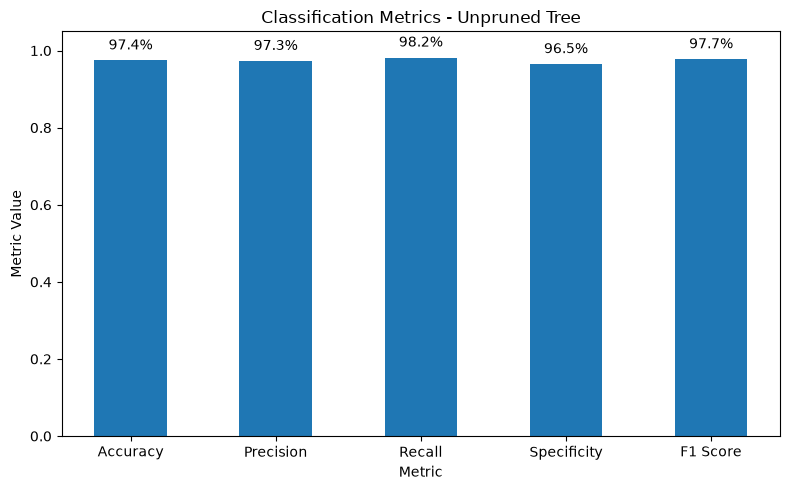

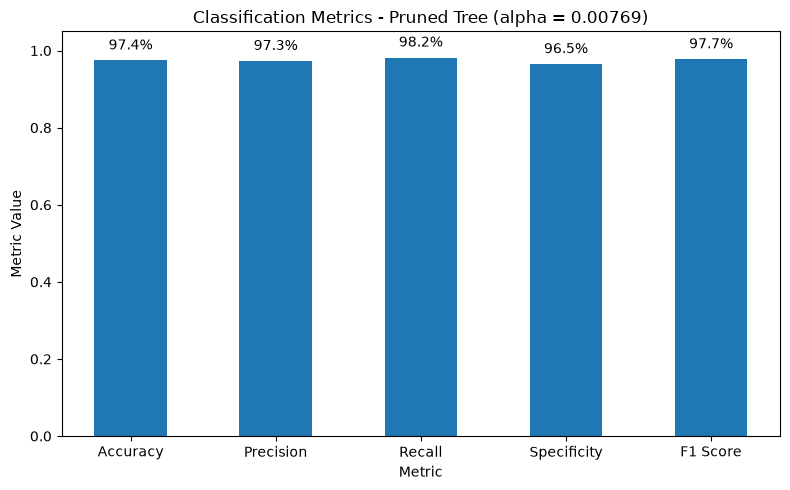

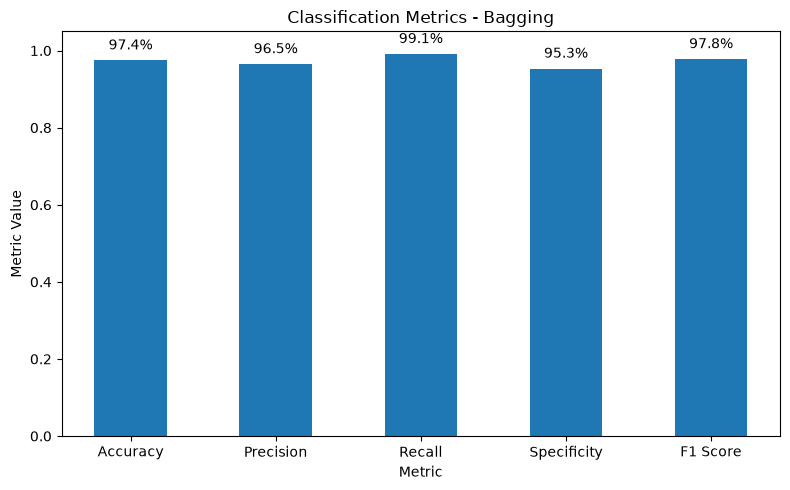

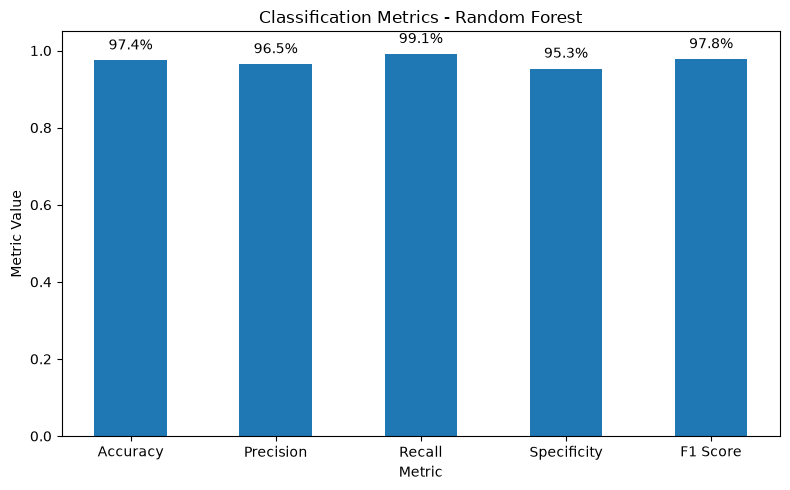

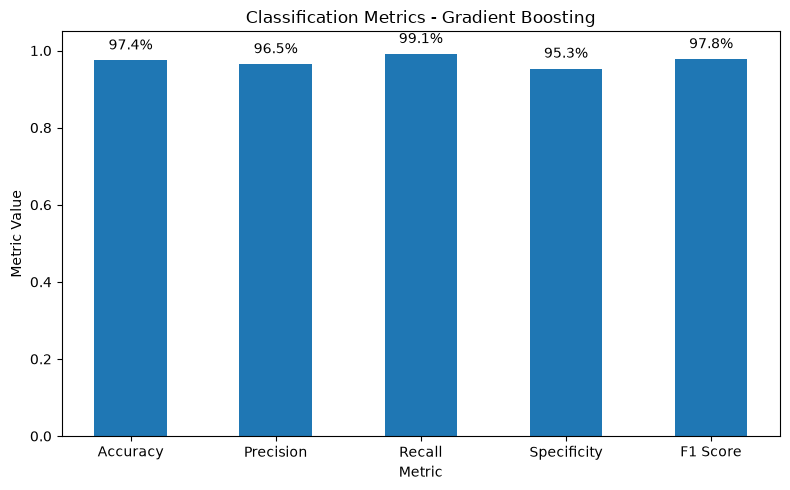

In [31]:
plot_metric_bars(tree_results)

#### 5.3.9 Random Forest Feature Importance

Random Forest provides impurity-based feature importance values. These show how strongly predictors contributed to reducing impurity across the forest's splits.

Because correlated predictors can share or redistribute importance, the ranking should be interpreted as model-specific rather than as a definitive causal ranking.

In [32]:
random_forest_pipeline.fit(X_train, y_train)

rf_feature_names = clean_feature_names(
    random_forest_pipeline["preprocessing"].get_feature_names_out()
)

rf_importance_df = pd.DataFrame({
    "Feature": rf_feature_names,
    "Importance": random_forest_pipeline["model"].feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

rf_importance_df.round(3)

,Feature,Importance
7,ISI,0.302
4,FFMC,0.272
9,FWI,0.161
5,DMC,0.065
3,Rain,0.060
8,BUI,0.060
6,DC,0.043
0,Temperature,0.017
1,RH,0.009
2,Ws,0.004


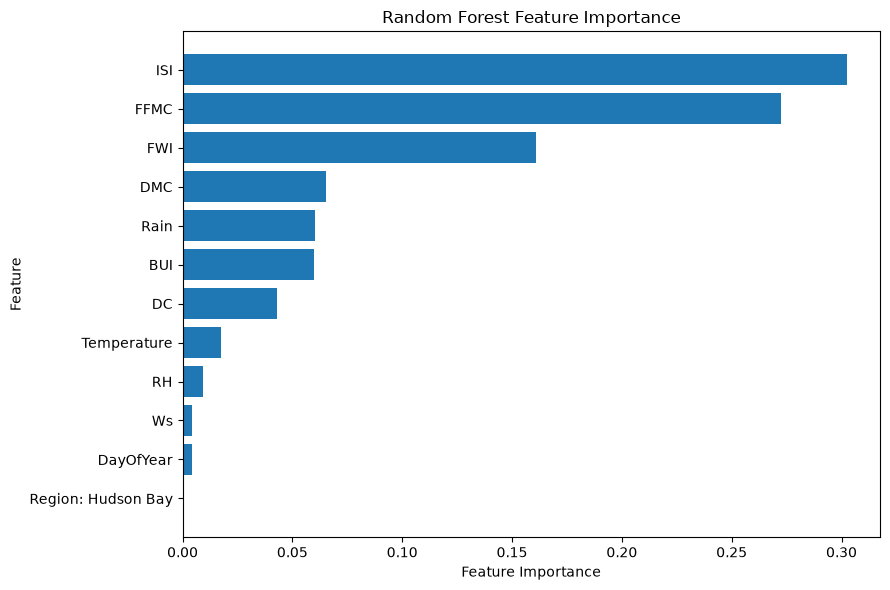

In [33]:
plt.figure(figsize=(9, 6))

plt.barh(
    rf_importance_df["Feature"],
    rf_importance_df["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### 5.4 Support Vector Machines

Support Vector Machines classify observations by finding a decision boundary with a large margin between classes. Numerical scaling is required because SVMs are sensitive to feature magnitudes.

The assignment requires different kernels and values of cost (`C`), `gamma`, and polynomial degree. These are compared using five-fold stratified cross-validation.

#### 5.4.1 Hyperparameter Search

Three kernels are considered:

- **Linear:** controlled mainly by `C`.
- **RBF:** controlled by `C` and `gamma`.
- **Polynomial:** controlled by `C`, `gamma`, and `degree`.

`C` controls the penalty for classification errors. Larger values penalize errors more strongly. `gamma` controls how local the influence of individual observations is for nonlinear kernels, while `degree` controls the polynomial order.

In [34]:
svm_search_pipeline = Pipeline([
    ("preprocessing", scaled_preprocessor),
    ("model", SVC())
])

svm_param_grid = [
    {
        "model__kernel": ["linear"],
        "model__C": [0.1, 1, 10, 100]
    },
    {
        "model__kernel": ["rbf"],
        "model__C": [0.1, 1, 10],
        "model__gamma": ["scale", 0.01, 0.1, 1]
    },
    {
        "model__kernel": ["poly"],
        "model__C": [0.1, 1, 10],
        "model__gamma": ["scale", 0.01, 0.1],
        "model__degree": [2, 3, 4]
    }
]

svm_grid_search = GridSearchCV(
    estimator=svm_search_pipeline,
    param_grid=svm_param_grid,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    refit=True
)

svm_grid_search.fit(X_train, y_train)

print("Best SVM parameters:")
print(svm_grid_search.best_params_)
print("Best mean CV accuracy:", round(svm_grid_search.best_score_, 3))

Best SVM parameters:
{'model__C': 10, 'model__kernel': 'linear'}
Best mean CV accuracy: 0.974


#### 5.4.2 Comparison of SVM Kernels

The best cross-validation result achieved within each kernel family is summarized below. This verifies that the linear, RBF, and polynomial kernels were all examined rather than reporting only the overall winning configuration.

In [35]:
svm_tuning_results = pd.DataFrame(
    svm_grid_search.cv_results_
)

best_kernel_rows = (
    svm_tuning_results
    .groupby("param_model__kernel")["mean_test_score"]
    .idxmax()
)

svm_kernel_summary = svm_tuning_results.loc[
    best_kernel_rows,
    [
        "param_model__kernel",
        "param_model__C",
        "param_model__gamma",
        "param_model__degree",
        "mean_test_score"
    ]
].copy()

svm_kernel_summary.columns = [
    "Kernel",
    "C",
    "Gamma",
    "Degree",
    "CV Accuracy"
]

svm_kernel_summary = svm_kernel_summary.sort_values(
    "CV Accuracy",
    ascending=False
)

svm_kernel_summary.round(3)

,Kernel,C,Gamma,Degree,CV Accuracy
2,linear,10.0,NaN,NaN,0.974
12,rbf,10.0,scale,NaN,0.949
39,poly,10.0,0.1,3.0,0.892


**Development result.** The linear kernel with `C = 10` performs best (CV accuracy 0.974), compared with 0.949 for the best RBF configuration and 0.892 for the best polynomial configuration. The nonlinear kernels therefore do not improve performance for this dataset under the tested parameter values.

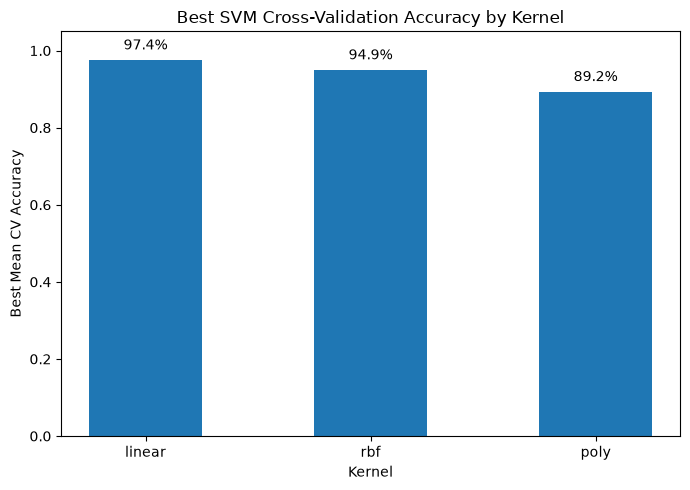

In [36]:
plt.figure(figsize=(7, 5))

bars = plt.bar(
    svm_kernel_summary["Kernel"],
    svm_kernel_summary["CV Accuracy"],
    width=0.5
)

plt.xlabel("Kernel")
plt.ylabel("Best Mean CV Accuracy")
plt.title("Best SVM Cross-Validation Accuracy by Kernel")
plt.ylim(0, 1.05)

for bar, value in zip(bars, svm_kernel_summary["CV Accuracy"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value * 100:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

#### 5.4.3 Selected SVM Model

The best cross-validated SVM configuration is rebuilt as the selected SVM pipeline. ROC/AUC uses the SVM decision function, which provides a continuous ranking score without requiring probability calibration.

In [37]:
best_svm_params = {
    key.replace("model__", ""): value
    for key, value in svm_grid_search.best_params_.items()
}

best_svm_pipeline = Pipeline([
    ("preprocessing", scaled_preprocessor),
    ("model", SVC(**best_svm_params))
])

best_svm_name = f'SVM ({best_svm_params["kernel"]})'

svm_results = {
    best_svm_name: evaluate_cv_model(
        best_svm_pipeline,
        X_train,
        y_train,
        cv
    )
}

results_table(svm_results).round(3)

,Model,Accuracy,Precision,Recall,Specificity,F1 Score,ROC-AUC
0,SVM (linear),0.974,0.965,0.991,0.953,0.978,0.998


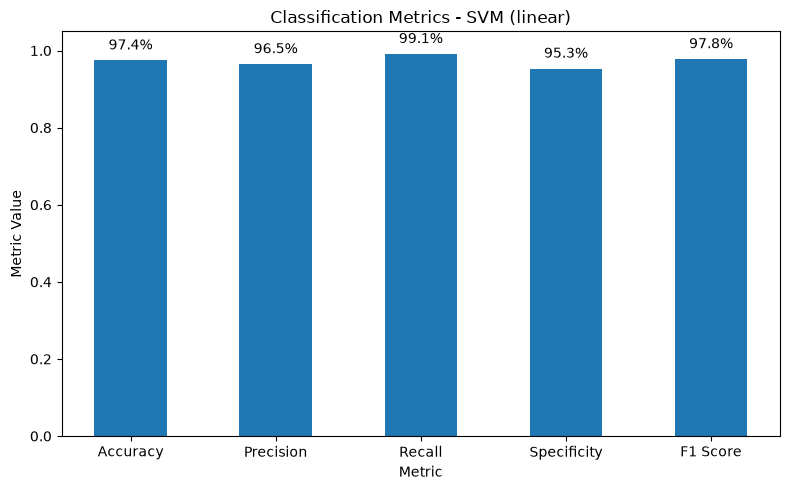

In [38]:
plot_metric_bars(svm_results)

### 5.5 Overall Model Comparison and Final Test Evaluation

All hyperparameter choices have now been made using the training data. No further tuning is performed after this point.

The assignment requires models to be fitted on the training set and evaluated on the test set, with confusion matrices, performance metrics, ROC curves, and AUC values reported. The final test comparison therefore evaluates each finalized classifier once on the held-out test set. fileciteturn7file0

#### 5.5.1 Cross-Validated Development Comparison

Before using the test set, the out-of-fold results from all finalized model families are combined into one development table. This summarizes how the models compared during training and tuning.

In [39]:
all_cv_results = {
    **results_5_1,
    **knn_results,
    **tree_results,
    **svm_results
}

cv_comparison = results_table(
    all_cv_results,
    include_auc=True
).sort_values(
    "Accuracy",
    ascending=False
)

cv_comparison.round(3)

,Model,Accuracy,Precision,Recall,Specificity,F1 Score,ROC-AUC
4,Unpruned Tree,0.974,0.973,0.982,0.965,0.977,0.973
5,Pruned Tree (alpha = 0.00769),0.974,0.973,0.982,0.965,0.977,0.973
8,Gradient Boosting,0.974,0.965,0.991,0.953,0.978,0.978
9,SVM (linear),0.974,0.965,0.991,0.953,0.978,0.998
7,Random Forest,0.974,0.965,0.991,0.953,0.978,0.998
6,Bagging,0.974,0.965,0.991,0.953,0.978,0.999
2,QDA,0.964,0.956,0.982,0.941,0.969,0.984
0,Logistic Regression,0.964,0.964,0.973,0.953,0.968,0.995
1,LDA,0.928,0.944,0.927,0.929,0.936,0.980
3,KNN (K = 21),0.918,0.905,0.955,0.871,0.929,0.976


#### 5.5.2 Final Test-Set Evaluation

After model development is complete, every finalized classifier is fitted to the full training set and evaluated on the same held-out test set. No tuning or preprocessing choice is changed after examining these test results.

The table reports accuracy, precision, recall (sensitivity), specificity, F1 score, and ROC-AUC. Because the test set contains only 49 observations, differences of a single prediction correspond to roughly two percentage points of accuracy and should not be over-interpreted.

In [40]:
final_models = {
    "Logistic Regression": logistic_pipeline,
    "LDA": lda_pipeline,
    "QDA": qda_pipeline,
    f"KNN (K = {best_k})": best_knn_pipeline,
    "Unpruned Tree": unpruned_tree_pipeline,
    f"Pruned Tree (alpha = {best_alpha:.5f})": pruned_tree_pipeline,
    "Bagging": bagging_pipeline,
    "Random Forest": random_forest_pipeline,
    "Gradient Boosting": boosting_pipeline,
    best_svm_name: best_svm_pipeline
}

test_results = {}

for model_name, model in final_models.items():
    fitted_model = clone(model)
    fitted_model.fit(X_train, y_train)

    y_test_pred = fitted_model.predict(X_test)
    y_test_score = continuous_score(fitted_model, X_test)

    test_results[model_name] = classification_summary(
        y_test,
        y_test_pred,
        y_test_score
    )

final_test_comparison = results_table(
    test_results,
    include_auc=True
).sort_values(
    ["Accuracy", "ROC-AUC"],
    ascending=[False, False]
)

final_test_comparison.round(3)

,Model,Accuracy,Precision,Recall,Specificity,F1 Score,ROC-AUC
6,Bagging,0.980,0.966,1.000,0.952,0.982,0.998
2,QDA,0.980,0.966,1.000,0.952,0.982,0.997
4,Unpruned Tree,0.980,0.966,1.000,0.952,0.982,0.976
5,Pruned Tree (alpha = 0.00769),0.980,0.966,1.000,0.952,0.982,0.976
8,Gradient Boosting,0.980,0.966,1.000,0.952,0.982,0.976
7,Random Forest,0.959,0.964,0.964,0.952,0.964,0.998
0,Logistic Regression,0.959,0.964,0.964,0.952,0.964,0.997
9,SVM (linear),0.959,0.964,0.964,0.952,0.964,0.997
1,LDA,0.939,0.963,0.929,0.952,0.945,0.991
3,KNN (K = 21),0.939,0.931,0.964,0.905,0.947,0.984


In [41]:
# Compare development accuracy with held-out test performance.
cv_accuracy = cv_comparison[["Model", "Accuracy"]].rename(
    columns={"Accuracy": "CV Accuracy"}
)

test_accuracy = final_test_comparison[["Model", "Accuracy", "ROC-AUC"]].rename(
    columns={"Accuracy": "Test Accuracy", "ROC-AUC": "Test ROC-AUC"}
)

generalization_summary = cv_accuracy.merge(
    test_accuracy,
    on="Model",
    how="inner"
).sort_values(
    ["Test Accuracy", "Test ROC-AUC"],
    ascending=[False, False]
)

generalization_summary.round(3)

,Model,CV Accuracy,Test Accuracy,Test ROC-AUC
5,Bagging,0.974,0.980,0.998
6,QDA,0.964,0.980,0.997
0,Unpruned Tree,0.974,0.980,0.976
1,Pruned Tree (alpha = 0.00769),0.974,0.980,0.976
2,Gradient Boosting,0.974,0.980,0.976
4,Random Forest,0.974,0.959,0.998
3,SVM (linear),0.974,0.959,0.997
7,Logistic Regression,0.964,0.959,0.997
8,LDA,0.928,0.939,0.991
9,KNN (K = 21),0.918,0.939,0.984


#### 5.5.3 Final Test Confusion Matrices

The following confusion matrices show the final test-set classification outcomes for each finalized model.

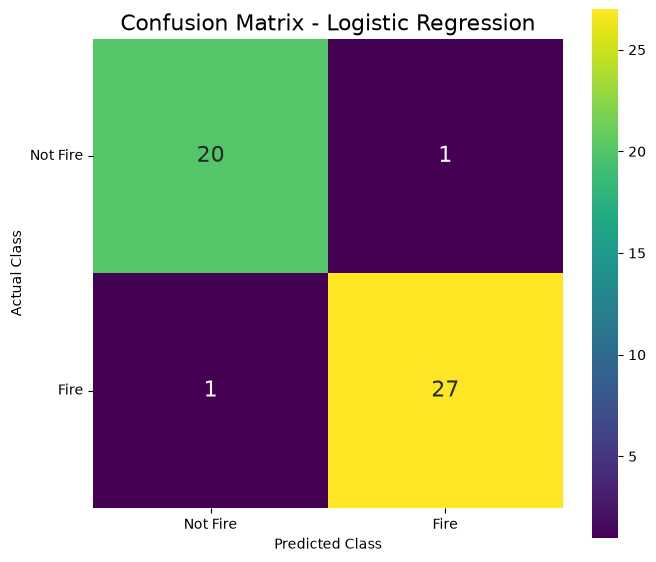

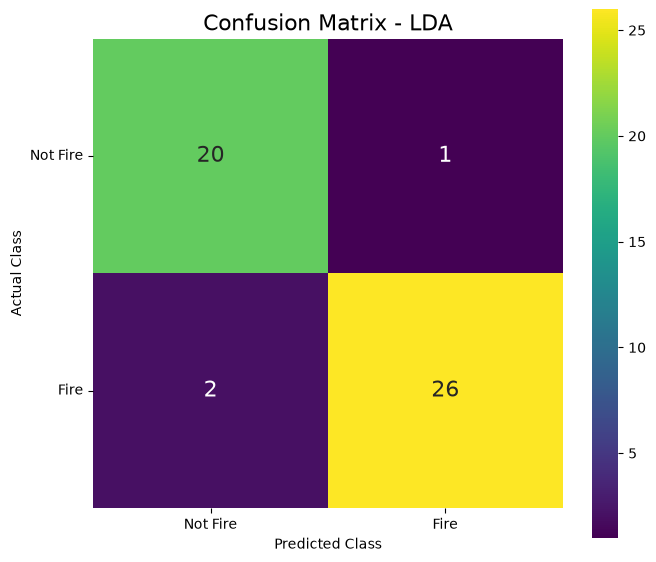

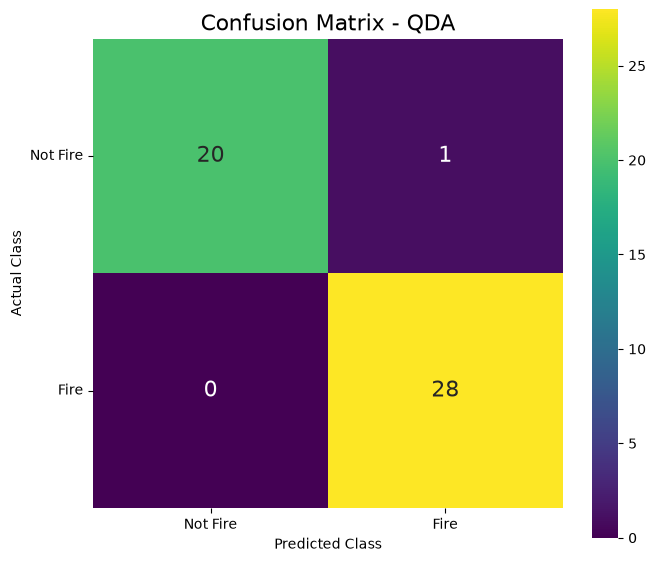

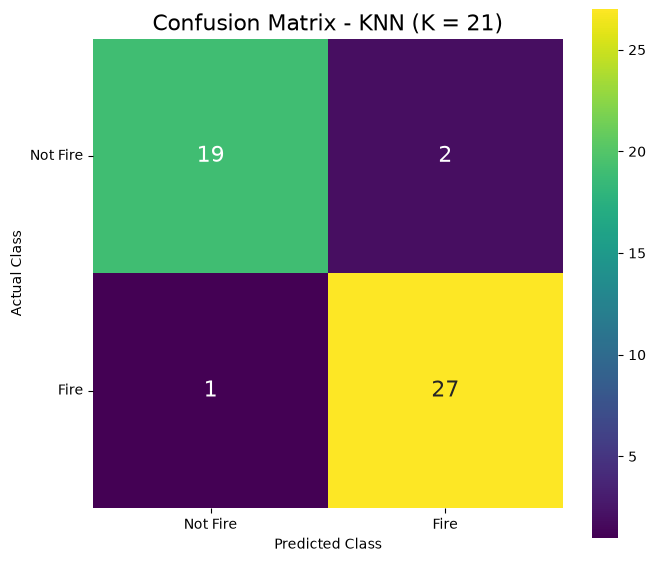

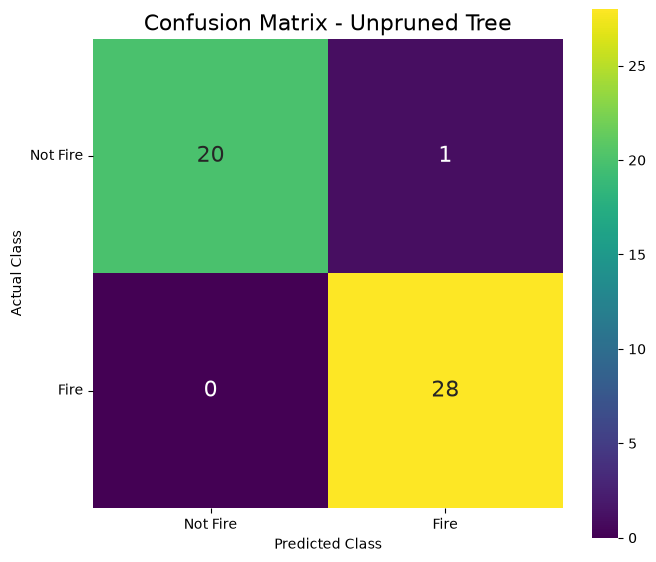

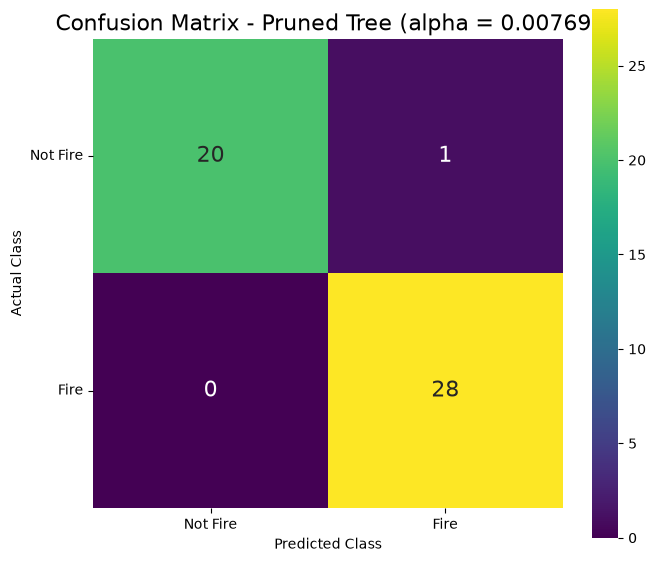

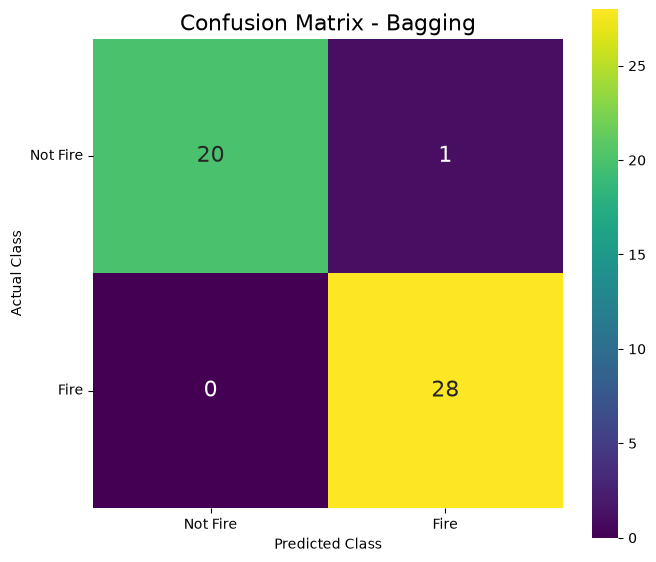

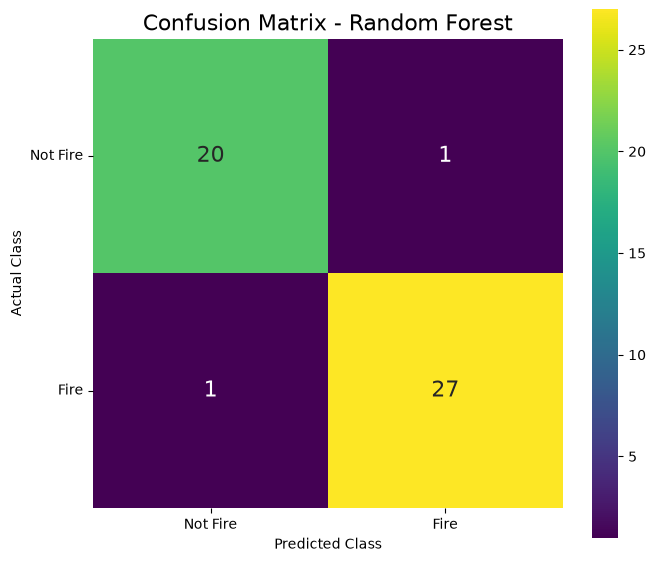

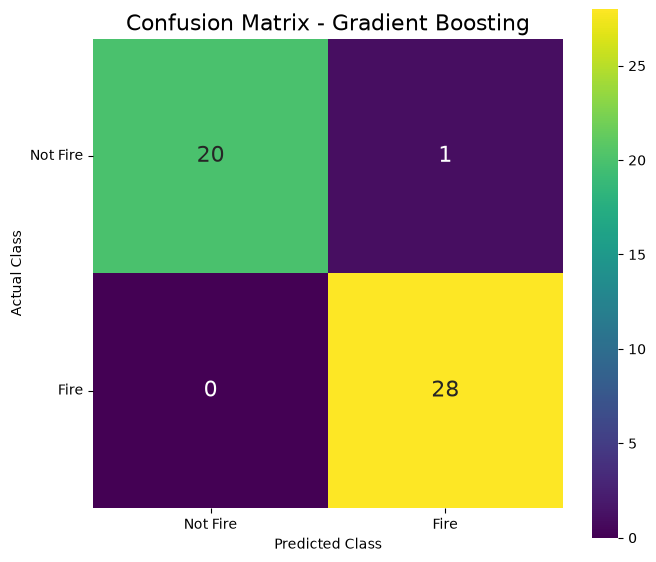

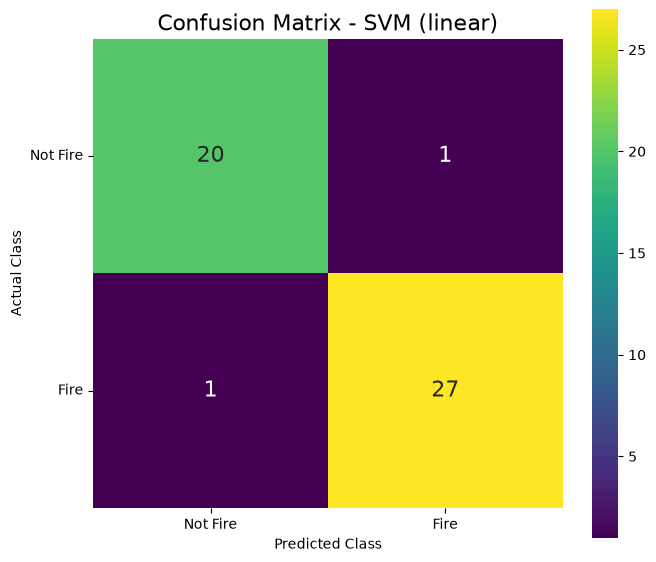

In [42]:
plot_confusion_matrices(test_results)

#### 5.5.4 Final Test ROC Curves and AUC

The ROC curves below compare the discriminatory performance of all finalized classifiers on the same held-out test observations. AUC values are shown in the legend.

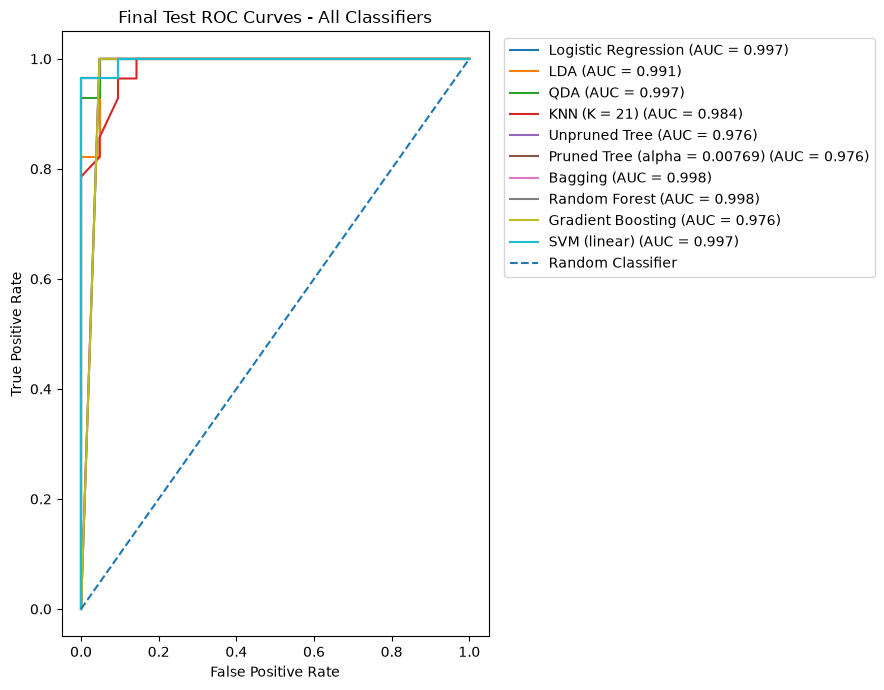

In [43]:
plot_roc_curves(
    test_results,
    y_test,
    "Final Test ROC Curves - All Classifiers"
)

#### 5.5.5 Final Results Interpretation

The held-out test results show very strong predictive performance across several model families, but there is no unique winner by accuracy alone.

- **Top test accuracy (0.980)** is shared by Bagging, QDA, Gradient Boosting, the unpruned tree, and the pruned tree. Each of these models identifies all fire observations in the test set (`Recall = 1.000`) while maintaining specificity of 0.952.
- **Bagging provides the strongest overall balance among the top-accuracy models**, with test ROC-AUC of 0.998 and cross-validated ROC-AUC of 0.999. QDA is also competitive on the test set (AUC 0.997), although its development accuracy was slightly lower at 0.964.
- Random Forest, Logistic Regression, and the selected linear SVM each achieve test accuracy of 0.959. Their AUC values remain very high, showing that a small number of threshold-dependent classification errors can coexist with strong overall ranking ability.
- LDA and KNN have the lowest test accuracies (0.939). KNN's lower specificity indicates that its main weakness is a greater tendency to label not-fire observations as fire.
- The pruned and unpruned trees have identical CV and test accuracy, while pruning reduces structural complexity. This means the simpler pruned tree achieves the same predictive performance and is preferable when interpretability is important.

Because the test set contains only 49 observations, several models differ by only one or two predictions. The results therefore support a group of strong models rather than a claim that one method is universally superior.

## 6. Discussion and Conclusion

### 6.1 Main Findings and Model Choice

The models consistently show that forest-fire occurrence can be predicted accurately from the available weather and Fire Weather Index variables in this dataset.

For a **predictive choice**, Bagging is the strongest overall candidate: it belongs to the highest test-accuracy group, detects every fire observation in the test set, and has the highest or near-highest AUC in both development and test evaluation. However, the difference from several alternatives is small.

For an **interpretable choice**, the pruned decision tree is attractive because it reaches the same test accuracy as Bagging while using a very small tree. This illustrates an important trade-off between maximum ensemble robustness and model simplicity.

Feature interpretation also shows a consistent pattern. `ISI`, `FFMC`, and `FWI` are the three largest Random Forest importance values, and `FFMC`, `ISI`, and `FWI` are also the largest standardized Logistic Regression coefficients. Their agreement supports the conclusion that these Fire Weather Index components contain substantial predictive signal. Because FWI variables are strongly correlated, their individual importance values should be interpreted as model-specific contributions rather than causal effects.

### 6.2 Effect of Preprocessing and Hyperparameter Choices

The preprocessing strategy was model-specific rather than applying the same transformation to every classifier:

- `Region` was one-hot encoded because scikit-learn estimators require numeric inputs.
- Numerical predictors were standardized for Logistic Regression, LDA/QDA, KNN, and SVM. Scaling is especially important for KNN and SVM because their behavior depends on distances or margins; it also keeps the regularized Logistic Regression coefficients on comparable scales.
- Tree-based models used the original numerical scales because tree splits depend on ordering and threshold rules, not Euclidean distance.
- No imputation was needed because the cleaned data contain no missing values.
- No class-balancing method was introduced because the training classes are reasonably balanced.
- `DayOfYear` replaced `day`, `month`, and the constant `year` to provide one continuous temporal position variable.

The project did not fit explicit unscaled/alternative-preprocessing control models, so it would be inappropriate to claim a measured accuracy gain caused by scaling itself. Instead, preprocessing was chosen to make each model mathematically appropriate and to prevent data leakage by fitting learned transformations inside cross-validation pipelines.

Hyperparameter selection did show measurable model effects: KNN performance varied with `K` and was best at `K = 21`; cost-complexity pruning simplified the decision tree without reducing accuracy; and the SVM search showed that the linear kernel with `C = 10` outperformed the tested nonlinear alternatives.

### 6.3 Challenges and Limitations

Several limitations should be considered when interpreting the results:

- The raw file required non-standard reconstruction and contained one malformed observation that had to be repaired explicitly before analysis.
- The dataset is small (244 observations), and the final test set contains only 49 observations. Consequently, a single test error changes accuracy by about two percentage points.
- Several Fire Weather Index predictors are strongly correlated. This can make individual Logistic Regression coefficients and impurity-based tree importance values unstable or distributed across related predictors.
- All observations come from two regions and one fire season in 2012. Performance on other years, regions, or climate conditions is therefore not established by this analysis.
- Hyperparameters were selected using cross-validation on the training set. The held-out test set provides the independent final check, but larger external validation data would be needed for stronger claims of generalization.

These limitations do not invalidate the strong results, but they mean the reported performance should be interpreted as evidence for this dataset rather than a guaranteed operational fire-warning accuracy.

### 6.4 Conclusion

The analysis demonstrates that the available weather and FWI variables provide strong predictive information for distinguishing `fire` from `not fire` observations. Multiple classifiers achieve high accuracy, recall, F1 score, and ROC-AUC on the held-out test data.

Bagging provides the strongest overall predictive profile, while the pruned decision tree offers nearly the same practical performance with substantially greater interpretability. Across both Logistic Regression and Random Forest interpretation, `FFMC`, `ISI`, and `FWI` emerge as especially influential predictors.

The project also shows that model choice should not be based on accuracy alone. Comparing sensitivity, specificity, F1 score, ROC-AUC, model complexity, and cross-validation behavior gives a more complete view of performance and helps distinguish between models that appear similar from one metric.